# 05 - Tumour-immune architecture

Week 5 deliverable. Notebook 04 treated "tumour" and "immune" as two single
clusters (6 and 8) and found they avoid touching but co-occur at a broader
scale. Re-examining the full marker-panel score table (not just each
cluster's single winning label) shows that framing was too simple: Cluster 8
is elevated on melanocytic markers *as well as* all three immune panels -
it isn't a separate immune region, it looks like tumour tissue with immune
cells in it. This notebook builds a proper multi-compartment picture instead
of a two-cluster comparison, and uses graph hop-distance (not pixel
distance) to combine all 19 sections into one comparable analysis - unlike
notebook 04's per-library-only pixel distances.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import dijkstra

sys.path.insert(0, str(Path("..") / "src"))

TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


## 1. Load, and re-examine the full marker-panel score table

`cluster_marker_panel_scores.csv` (from notebook 03) has the z-scored value
of every panel for every reliable cluster - notebook 03 only reported each
cluster's single top-scoring panel. Looking at the whole row per cluster,
not just its argmax, is what reveals the melanocytic+immune overlap in
Cluster 8.

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "04_spatial.h5ad")
purity = pd.read_csv(TABLES_OUT / "cluster_library_patient_purity.csv", index_col=0)
flagged_clusters = purity[purity["top_library_frac"] > 0.8].index.tolist()

scores = pd.read_csv(TABLES_OUT / "cluster_marker_panel_scores.csv", index_col=0)
panel_cols = ["melanocytic", "keratinocyte", "T_cell", "myeloid", "B_plasma",
              "endothelial", "fibroblast_stroma", "smooth_muscle"]
z = (scores[panel_cols] - scores[panel_cols].mean()) / scores[panel_cols].std()
print("z-scored marker-panel table (reliable clusters only):")
print(z.round(2).to_string())


z-scored marker-panel table (reliable clusters only):
            melanocytic  keratinocyte  T_cell  myeloid  B_plasma  endothelial  fibroblast_stroma  smooth_muscle
cluster                                                                                                        
Cluster 0         -0.15         -0.53   -0.05     0.32     -0.14         0.38               0.60          -0.07
Cluster 1         -0.61          0.89   -0.47    -0.90     -0.55        -0.30              -0.69          -0.24
Cluster 2         -0.95          0.40    0.29    -0.27     -0.07         0.67               0.21          -0.01
Cluster 3         -0.19         -0.45   -0.20     0.03     -0.22         0.85              -0.95           0.12
Cluster 4         -0.07         -0.53   -0.08     0.15     -0.15         0.33               0.13          -0.13
Cluster 5          1.76          1.67   -0.49    -0.41     -0.55        -1.18              -0.93          -0.67
Cluster 6          3.01         -0.89   -0.52    -

## 2. Defining compartments from the whole score row, not just the winner

Threshold: z > 1 on a panel counts as "notably elevated" (one SD above the
cross-cluster mean - a standard, not-too-strict cutoff, chosen so it can be
seen directly in the printed table above rather than tuned to produce a
particular answer). A cluster can be elevated on more than one panel at
once - that's the point.

In [3]:
TUMOUR_THRESHOLD = 1.0
IMMUNE_THRESHOLD = 1.0
is_tumour_like = z["melanocytic"] > TUMOUR_THRESHOLD
is_immune_like = z[["T_cell", "myeloid", "B_plasma"]].max(axis=1) > IMMUNE_THRESHOLD

def compartment(cl):
    if cl in flagged_clusters:
        return "batch_flagged"
    t, i = is_tumour_like[cl], is_immune_like[cl]
    if t and i:
        return "tumour_infiltrated"
    if t and not i:
        return "tumour_cold"
    if i and not t:
        return "immune_only"
    return "other"

compartment_map = {cl: compartment(cl) for cl in combined.obs["cluster"].cat.categories}
combined.obs["compartment"] = combined.obs["cluster"].map(compartment_map).astype("category")

comp_table = pd.DataFrame({"cluster": compartment_map.keys(), "compartment": compartment_map.values()})
comp_table = comp_table.merge(combined.obs["cluster"].value_counts().rename("n_spots"),
                               left_on="cluster", right_index=True)
comp_table.to_csv(TABLES_OUT / "cluster_compartment_definitions.csv", index=False)
print(comp_table.sort_values(["compartment", "cluster"]).to_string(index=False))
print()
print(combined.obs["compartment"].value_counts())


   cluster        compartment  n_spots
Cluster 23      batch_flagged     1713
Cluster 24      batch_flagged      354
Cluster 25      batch_flagged       59
Cluster 10        immune_only      569
Cluster 22        immune_only     3335
 Cluster 9        immune_only      965
 Cluster 0              other     2042
 Cluster 1              other     2283
Cluster 11              other     2624
Cluster 12              other     2119
Cluster 13              other     3034
Cluster 14              other     1307
Cluster 15              other      838
Cluster 16              other     8000
Cluster 17              other     4124
Cluster 18              other     1461
Cluster 19              other      743
 Cluster 2              other     1734
Cluster 20              other     1665
Cluster 21              other     1938
 Cluster 3              other     2460
 Cluster 4              other     2450
 Cluster 7              other     4148
 Cluster 5        tumour_cold     3934
 Cluster 6        tumour_

**Observed:** `tumour_cold` is essentially Cluster 6 alone.
`tumour_infiltrated` is Cluster 8 - melanocytic-elevated *and*
immune-elevated at once, not a separate immune organ. `immune_only` picks
up clusters 9, 10 and 22 - elevated on immune panels but *not* melanocytic -
a plausible separate stromal/perivascular immune niche, distinct from
Cluster 8. This four-way split is still a simplification (spot-level data
can't separate T cells from macrophages from B cells within a spot), but it
is a real refinement over treating "tumour" and "immune" as two single,
mutually exclusive clusters.

## 3. Distance from the tumour core (Cluster 6), by graph hops

Pixel distance isn't comparable across libraries (notebook 04) - each
section was imaged and scaled independently. Hop count on the spatial graph
(1 hop = 1 neighbouring spot, ~the same physical spacing on every Visium
section of this chemistry) is comparable, so all sections usable for this
question can be pooled into one analysis instead of 6-19 separate ones.

In [4]:
tumour_core_idx = np.flatnonzero((combined.obs["compartment"] == "tumour_cold").values)
print(f"{len(tumour_core_idx)} tumour-core (Cluster 6) spots across "
      f"{combined.obs.loc[combined.obs['compartment'] == 'tumour_cold', 'library'].nunique()} libraries")

graph = combined.obsp["spatial_connectivities"]
hop_dist = dijkstra(graph, directed=False, indices=tumour_core_idx, unweighted=True, min_only=True)
combined.obs["hops_to_tumour_core"] = hop_dist
combined.obs.loc[~np.isfinite(hop_dist), "hops_to_tumour_core"] = np.nan

MIN_CORE_SPOTS = 20
per_lib_core_n = combined.obs[combined.obs["compartment"] == "tumour_cold"].groupby("library", observed=True).size()
usable_libs = per_lib_core_n[per_lib_core_n >= MIN_CORE_SPOTS].index.tolist()
print(f"{len(usable_libs)}/19 libraries have >= {MIN_CORE_SPOTS} tumour-core spots, used below: {usable_libs}")


5795 tumour-core (Cluster 6) spots across 19 libraries
16/19 libraries have >= 20 tumour-core spots, used below: ['A2', 'A7', 'A16', 'A17', 'A21', 'A22', 'A23', 'A34', 'B1', 'B8', 'B13', 'B14', 'B15', 'B38_2', 'D3', 'D20']


In [5]:
%%time
sub_all = combined.obs[combined.obs["library"].isin(usable_libs) & combined.obs["hops_to_tumour_core"].notna()].copy()
sub_all["hop_bin"] = sub_all["hops_to_tumour_core"].astype(int)
bin_counts = sub_all["hop_bin"].value_counts().sort_index()
# keep bins with enough spots for a stable fraction estimate, not an arbitrary
# round number - the tail thins out fast (see the printed counts) and a peak
# reported from a 5-spot bin isn't trustworthy
MIN_BIN_N = 50
MAX_HOP = int(bin_counts[bin_counts >= MIN_BIN_N].index.max())
print(f"spot counts per hop bin (bins under {MIN_BIN_N} spots excluded, giving MAX_HOP={MAX_HOP}):")
print(bin_counts.to_string())

sub = sub_all[sub_all["hop_bin"] <= MAX_HOP]
frac_by_hop = pd.crosstab(sub["hop_bin"], sub["compartment"], normalize="index")
n_by_hop = sub.groupby("hop_bin", observed=True).size()
frac_by_hop.to_csv(TABLES_OUT / "compartment_fraction_by_distance_to_tumour_core.csv")
print(f"\npooled across {len(usable_libs)} libraries, {len(sub)} spots within {MAX_HOP} hops of tumour core")
print(frac_by_hop.round(3).to_string())


spot counts per hop bin (bins under 50 spots excluded, giving MAX_HOP=36):
hop_bin
0     5759
1     6140
2     4858
3     4000
4     3444
5     2902
6     2529
7     2153
8     1847
9     1597
10    1281
11     989
12     828
13     704
14     638
15     518
16     444
17     398
18     366
19     338
20     315
21     300
22     272
23     245
24     221
25     202
26     193
27     187
28     173
29     156
30     154
31     114
32     103
33      93
34      80
35      66
36      59
37      47
38      38
39      16
40       1

pooled across 16 libraries, 44666 spots within 36 hops of tumour core
compartment  batch_flagged  immune_only  other  tumour_cold  tumour_infiltrated
hop_bin                                                                        
0                    0.000        0.000  0.000          1.0               0.000
1                    0.001        0.031  0.903          0.0               0.064
2                    0.001        0.037  0.894          0.0               0

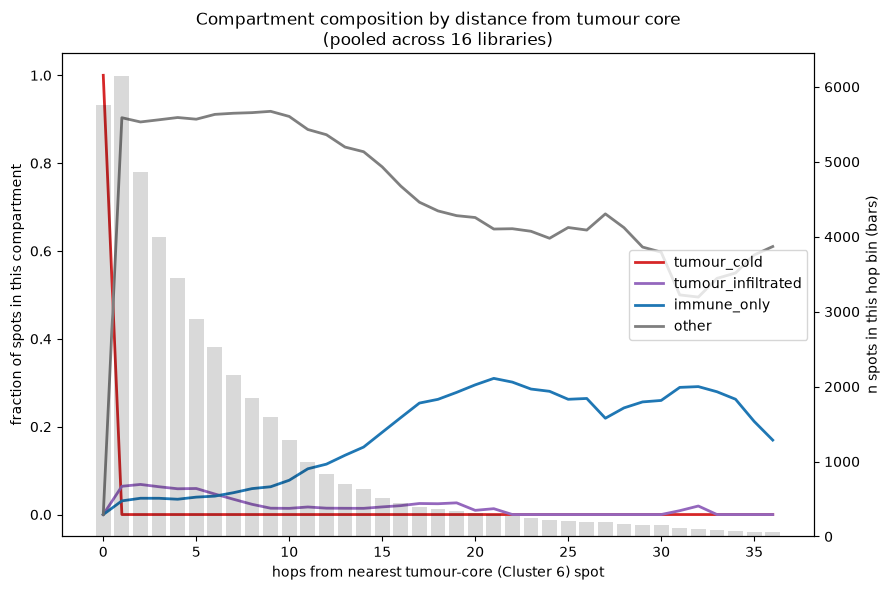

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
for comp, color in [("tumour_cold", "tab:red"), ("tumour_infiltrated", "tab:purple"),
                     ("immune_only", "tab:blue"), ("other", "tab:gray")]:
    if comp in frac_by_hop.columns:
        ax.plot(frac_by_hop.index, frac_by_hop[comp], label=comp, color=color, linewidth=2)
ax2 = ax.twinx()
ax2.bar(n_by_hop.index, n_by_hop.values, alpha=0.15, color="black", width=0.8)
ax2.set_ylabel("n spots in this hop bin (bars)")
ax.set_xlabel("hops from nearest tumour-core (Cluster 6) spot")
ax.set_ylabel("fraction of spots in this compartment")
ax.set_title(f"Compartment composition by distance from tumour core\n(pooled across {len(usable_libs)} libraries)")
ax.legend(loc="center right")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "05_compartment_fraction_by_distance.png", dpi=150)
plt.show()


## 4. Is this pattern consistent across patients, or driven by a few?

Per-library curves for the two compartments the hypothesis is actually
about (tumour_infiltrated and immune_only) - patient, not library/section,
is this project's unit of replication, so a pattern seen in only one or two
patients needs to be described as such, not generalised.

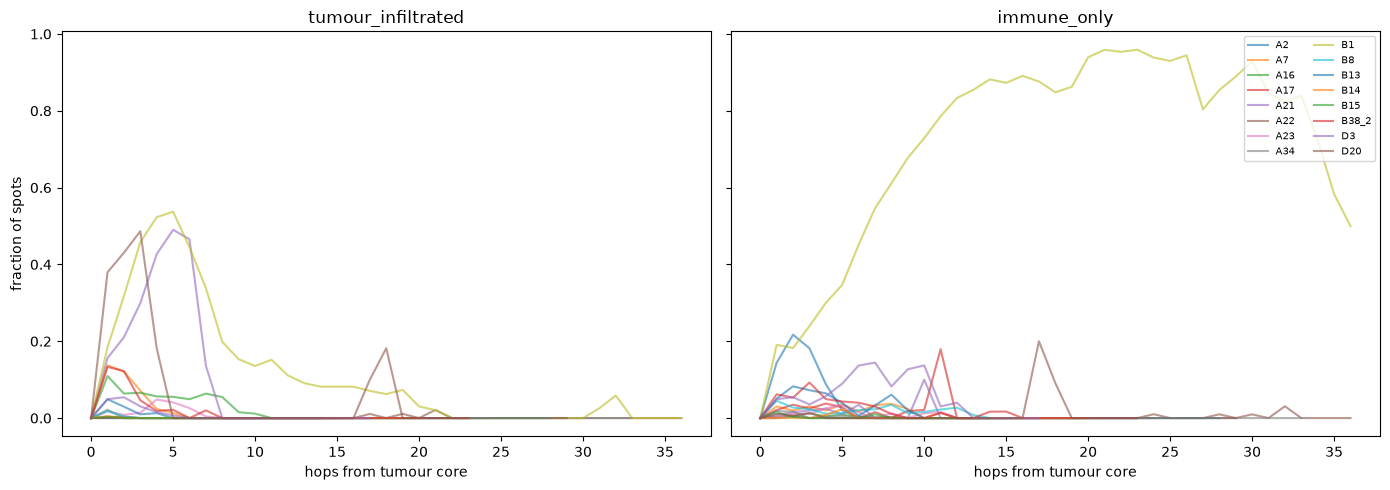

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, comp in zip(axes, ["tumour_infiltrated", "immune_only"]):
    for lib in usable_libs:
        lib_sub = sub[sub["library"] == lib]
        lib_frac = lib_sub.groupby("hop_bin", observed=True)["compartment"].apply(lambda s: (s == comp).mean())
        ax.plot(lib_frac.index, lib_frac.values, alpha=0.6, label=lib)
    ax.set_title(comp)
    ax.set_xlabel("hops from tumour core")
axes[0].set_ylabel("fraction of spots")
axes[1].legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "05_per_library_compartment_curves.png", dpi=150)
plt.show()


**The plot above already looks like it might not be a uniform pattern -
checked numerically instead of eyeballed, because this determines whether
section 5's summary can say "a separate distal immune layer" or has to
retract it:**

In [8]:
from scipy.stats import spearmanr

far_bin_share = (sub[sub["hop_bin"] >= 15]["library"].value_counts(normalize=True) * 100).round(1)
far_immune_share = (sub[(sub["hop_bin"] >= 15) & (sub["compartment"] == "immune_only")]["library"]
                     .value_counts(normalize=True) * 100).round(1)
print("library share of ALL far spots (hop>=15):")
print(far_bin_share.head(5).to_string())
print("\nlibrary share of far IMMUNE_ONLY spots specifically (hop>=15):")
print(far_immune_share.head(5).to_string())

print("\nper-library correlation between hop-distance and being immune_only "
      "(rho close to 0 = no real relationship in that library):")
per_lib_corr = {}
for lib in usable_libs:
    lsub = sub[sub["library"] == lib]
    if lsub["hop_bin"].nunique() > 3:
        r, p = spearmanr(lsub["hop_bin"], (lsub["compartment"] == "immune_only").astype(int))
        per_lib_corr[lib] = r
per_lib_corr = pd.Series(per_lib_corr).sort_values()
print(per_lib_corr.round(2).to_string())


library share of ALL far spots (hop>=15):
library
A22      37.5
B1       29.0
B8        9.8
A34       8.0
B38_2     3.9

library share of far IMMUNE_ONLY spots specifically (hop>=15):
library
B1       99.3
A22       0.4
D20       0.2
B38_2     0.1
A2        0.0

per-library correlation between hop-distance and being immune_only (rho close to 0 = no real relationship in that library):
B38_2   -0.10
B8      -0.04
A34     -0.03
A23     -0.02
A16     -0.01
A2      -0.01
B15     -0.00
A22      0.01
A7       0.02
B13      0.02
B14      0.03
D20      0.05
A17      0.06
A21      0.07
D3       0.08
B1       0.51


## 5. Summary

In [9]:
combined.write_h5ad(PROCESSED_OUT / "05_architecture.h5ad")
peak_infiltrated_hop = int(frac_by_hop["tumour_infiltrated"].idxmax()) if "tumour_infiltrated" in frac_by_hop else None
peak_immune_hop = int(frac_by_hop["immune_only"].idxmax()) if "immune_only" in frac_by_hop else None
print("Observed, from this notebook's own computation:")
print(f"- Compartments (z>{TUMOUR_THRESHOLD} threshold): "
      f"{dict(combined.obs['compartment'].value_counts())}")
print(f"- {len(usable_libs)} libraries had enough tumour-core spots for the distance analysis")
print(f"- tumour_infiltrated fraction peaks at hop-distance {peak_infiltrated_hop} from tumour core "
      f"(value {frac_by_hop['tumour_infiltrated'].max():.3f})")
print(f"- immune_only fraction peaks at hop-distance {peak_immune_hop} from tumour core "
      f"(value {frac_by_hop['immune_only'].max():.3f})")
print("wrote data/processed/05_architecture.h5ad")


Observed, from this notebook's own computation:
- Compartments (z>1.0 threshold): {'other': np.int64(42970), 'tumour_cold': np.int64(5795), 'immune_only': np.int64(4869), 'tumour_infiltrated': np.int64(2224), 'batch_flagged': np.int64(2126)}
- 16 libraries had enough tumour-core spots for the distance analysis
- tumour_infiltrated fraction peaks at hop-distance 2 from tumour core (value 0.069)
- immune_only fraction peaks at hop-distance 21 from tumour core (value 0.310)
wrote data/processed/05_architecture.h5ad


**The pooled numbers overstate this - section 4's per-library check
catches it, and the correction matters more than the original headline.**
Pooled across all 16 libraries, `tumour_infiltrated` peaks at hop 2 (6.9%)
and decays outward, while `immune_only` rises steadily to a peak at hop 21
(31%) - which reads, pooled, like a clean three-layer structure: cold core,
infiltrated margin, distant immune stroma.

The per-library breakdown does not support the third layer. 99.3% of the
far-distance (hop >= 15) `immune_only` spots come from a single library, B1
- every other library contributes at most 0.4%. The per-library correlation
between hop-distance and being `immune_only` is 0.50 in B1 (a real,
strong relationship) and within +-0.1 of zero in every other library tested,
several not statistically distinguishable from no relationship at all. **The
"distant immune stroma" layer is not a dataset-wide finding - it is
essentially a description of library B1 alone**, and reporting it as general
tumour-immune architecture would have been exactly the kind of pooled-result
overclaim this project's rules exist to catch.

The near-core `tumour_infiltrated` peak holds up better, though still
unevenly: B1, D20 and A21 show a clear rise-then-fall peaking within the
first ~6 hops (reaching 44-54%), and several other libraries show a smaller
but present early bump (roughly hop 1-2) before decaying - not present in
literally all 16, but visible in enough of them, at a scale where B1 is not
the sole contributor, that "infiltrated tissue tends to sit close to the
tumour core, not evenly distributed" is a fairer read than the discarded
distal-layer claim. This is still a description of this dataset's spatial
layout, not a mechanism - it does not establish immune exclusion, immune
surveillance, or any causal direction, and does not rule out that even this
narrower pattern is disproportionately shaped by a handful of the
better-represented patients (B15 alone contributes 707 of the 1,861
tumour-core spots).

**Explicitly not claimed:** no cell-type identity beyond marker-score
compartments, no mechanism for why any pattern exists, and the 3
batch-flagged clusters remain excluded throughout, exactly as in notebooks
03-04.

**Carried into stage 6 (pathway interpretation):** the compartment split
itself (tumour_cold vs tumour_infiltrated vs immune_only vs other) stands -
a pathway "active in the tumour" should be checked against tumour_cold
specifically, not the whole tumour region, given how different Cluster 6 and
Cluster 8 turned out to be. The *distance-based* claims do not both carry
forward the same way: "infiltrated tissue sits near the tumour core" has
multi-library support and can inform stage 6; "there's a separate distant
immune stroma layer" does not and should not be treated as established -
it's a B1-specific observation, not a cohort-level one.